In [13]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

import matplotlib.pyplot as plt

In [14]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = malignant, 1 = benign

In [15]:
X_normal = X[y == 1]
X_anomaly = X[y == 0]

In [16]:
scaler = StandardScaler()
X_normal_scaled = scaler.fit_transform(X_normal)
X_anomaly_scaled = scaler.transform(X_anomaly)

In [17]:
input_dim = X_normal_scaled.shape[1]

input_layer = Input(shape=(input_dim,))

# Encoder
x = Dense(32, activation='relu')(input_layer)
x = Dense(16, activation='relu')(x)
x = Dense(8, activation='relu')(x)

# Bottleneck
x = Dense(4, activation='relu')(x)

# Decoder
x = Dense(8, activation='relu')(x)
x = Dense(16, activation='relu')(x)
x = Dense(32, activation='relu')(x)
output_layer = Dense(input_dim, activation='linear')(x)

model = Model(inputs=input_layer, outputs=output_layer)

model.compile(optimizer='adam', loss='mse')

In [18]:
history = model.fit(
    X_normal_scaled,
    X_normal_scaled,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.9333 - val_loss: 1.0639
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9985 - val_loss: 1.0385
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8903 - val_loss: 0.9626
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9789 - val_loss: 0.8453
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7352 - val_loss: 0.7557
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6721 - val_loss: 0.6953
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5735 - val_loss: 0.6496
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6190 - val_loss: 0.6148
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5066 - val_loss: 0.5850
Epoch 10/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4615 - val_loss: 0.5782
Epoch 11/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4848 - val_loss: 0.5621
Epoch 12/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4583 - 

In [19]:
# Normal data
recon_normal = model.predict(X_normal_scaled)
error_normal = np.mean((X_normal_scaled - recon_normal)**2, axis=1)

# Anomaly data
recon_anomaly = model.predict(X_anomaly_scaled)
error_anomaly = np.mean((X_anomaly_scaled - recon_anomaly)**2, axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


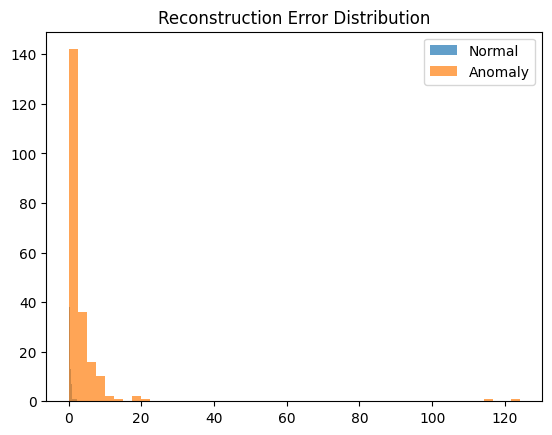

In [20]:
plt.hist(error_normal, bins=50, alpha=0.7, label='Normal')
plt.hist(error_anomaly, bins=50, alpha=0.7, label='Anomaly')
plt.legend()
plt.title("Reconstruction Error Distribution")
plt.show()

In [25]:
thresholds = np.linspace(0.5, 3.0, 10)

for t in thresholds:
    detected = np.sum(error_anomaly > t)
    print(f"Threshold {t:.2f} → Detected: {detected}/{len(error_anomaly)}")



Threshold 0.50 → Detected: 190/212
Threshold 0.78 → Detected: 166/212
Threshold 1.06 → Detected: 153/212
Threshold 1.33 → Detected: 131/212
Threshold 1.61 → Detected: 108/212
Threshold 1.89 → Detected: 98/212
Threshold 2.17 → Detected: 84/212
Threshold 2.44 → Detected: 72/212
Threshold 2.72 → Detected: 69/212
Threshold 3.00 → Detected: 59/212


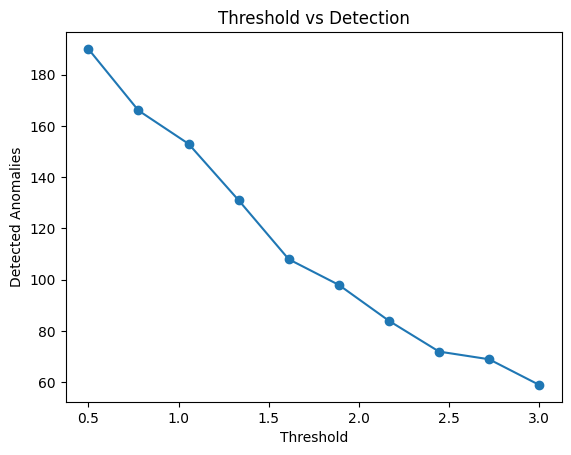

In [26]:
import matplotlib.pyplot as plt

thresholds = np.linspace(0.5, 3.0, 10)
detections = [190,166,153,131,108,98,84,72,69,59]

plt.plot(thresholds, detections, marker='o')
plt.xlabel("Threshold")
plt.ylabel("Detected Anomalies")
plt.title("Threshold vs Detection")
plt.show()

In [22]:
print("Normal mean error:", np.mean(error_normal))
print("Anomaly mean error:", np.mean(error_anomaly))

Normal mean error: 0.41606337750027744
Anomaly mean error: 3.849371955505494
